### **<u>Feature Selection: Wrapper Methods</u>**

Wrapper methods evaluate a subset of features by actually training a machine learning model on them and using the model's performance (e.g., accuracy, R2 score...) as the evaluation criterion. Unlike filter methods, they capture interactions between features but are computationally expensive.

**Common Wrapper Methods:**

1.  **Forward Selection:** Starts with an empty set of features and iteratively adds the feature that best improves model performance until no significant improvement is observed.
2.  **Backward Elimination:** Starts with all features and iteratively removes the least significant feature (the one whose removal least impacts performance) until a stopping criterion is met.
3.  **Recursive Feature Elimination (RFE):** Fits a model and removes the weakest feature(s) based on feature importance or coefficients, repeating the process until the desired number of features is reached.
4.  **Exhaustive Feature Selection:** Evaluates every possible combination of features. While guaranteed to find the best subset, it is computationally prohibitive for large feature sets.

In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score

In [2]:
# Loading the dataset
df = pd.read_csv('https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


#### Exhaustive Feature Selection (EFS)

Exhaustive Feature Selection is a **wrapper-based feature selection** technique that evaluates every possible combination of features to find the subset that yields the best performance for a specific machine learning model.

##### How it Works:
1.  **Combinatorial Search**: The algorithm starts by evaluating all possible subsets of features within a specified range (e.g., from 1 feature up to the total number of features available).
2.  **Model Training**: For every unique combination, a machine learning model is trained and evaluated using a performance metric (like accuracy, F1-score, or MSE), typically via cross-validation.
3.  **Selection**: After testing every single combination, the subset that achieved the highest performance score is selected as the optimal feature set.

> **Tie-breaking Rule**: If multiple feature subsets yield the same optimal performance score, the subset with the fewest features is selected to prioritize model parsimony and reduce complexity.

##### Key Characteristics:
*   **Global Optimum**: Unlike heuristic methods (such as Forward Selection or Backward Elimination) which might get stuck in local optima, EFS is guaranteed to find the best possible feature subset for the chosen model and metric because it looks at everything.
*   **Computational Complexity**: The main drawback is its cost. The number of combinations grows exponentially with the number of features ($2^n - 1$ combinations). For example, with 20 features, there are over a million combinations to test, making it impractical for high-dimensional datasets.
*   **Model Dependent**: Since it is a wrapper method, the "best" features are specific to the algorithm used during the selection process.

In [3]:
# Wrapper Method 1 - Exhaustive Feature Selection
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

sel = EFS(
    estimator=LogisticRegression(max_iter=250), # Default Parameters 
    max_features=4, # Maximum number of features to select. 
    print_progress=True,
    scoring='accuracy', 
    cv=5,
) # The max_features parameter specifies the maximum number of features to select from the dataset.

In [4]:
# Training feature selector
model = sel.fit(df.iloc[:,:4], df['species'])

Features: 15/15

In [5]:
# Highest scores among all the feature combinations
model.best_score_

np.float64(0.9733333333333334)

In [6]:
# Feature set have gotten highest score
model.best_feature_names_

('sepal_length', 'sepal_width', 'petal_length', 'petal_width')

In [7]:
# Detailed output
matric_df = pd.DataFrame.from_dict(model.subsets_).T
matric_df

,feature_idx,cv_scores,avg_score,feature_names
0,"(0,)","[0.6666666666666666, 0.7333333333333333, 0.766...",0.753333,"(sepal_length,)"
1,"(1,)","[0.5333333333333333, 0.5666666666666667, 0.533...",0.56,"(sepal_width,)"
2,"(2,)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(petal_length,)"
3,"(3,)","[1.0, 0.9666666666666667, 0.9, 0.9333333333333...",0.96,"(petal_width,)"
4,"(0, 1)","[0.7333333333333333, 0.8333333333333334, 0.766...",0.82,"(sepal_length, sepal_width)"
5,"(0, 2)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(sepal_length, petal_length)"
6,"(0, 3)","[0.9333333333333333, 0.9666666666666667, 0.933...",0.953333,"(sepal_length, petal_width)"
7,"(1, 2)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(sepal_width, petal_length)"
8,"(1, 3)","[0.9333333333333333, 0.9666666666666667, 0.9, ...",0.94,"(sepal_width, petal_width)"
9,"(2, 3)","[0.9666666666666667, 0.9666666666666667, 0.933...",0.96,"(petal_length, petal_width)"


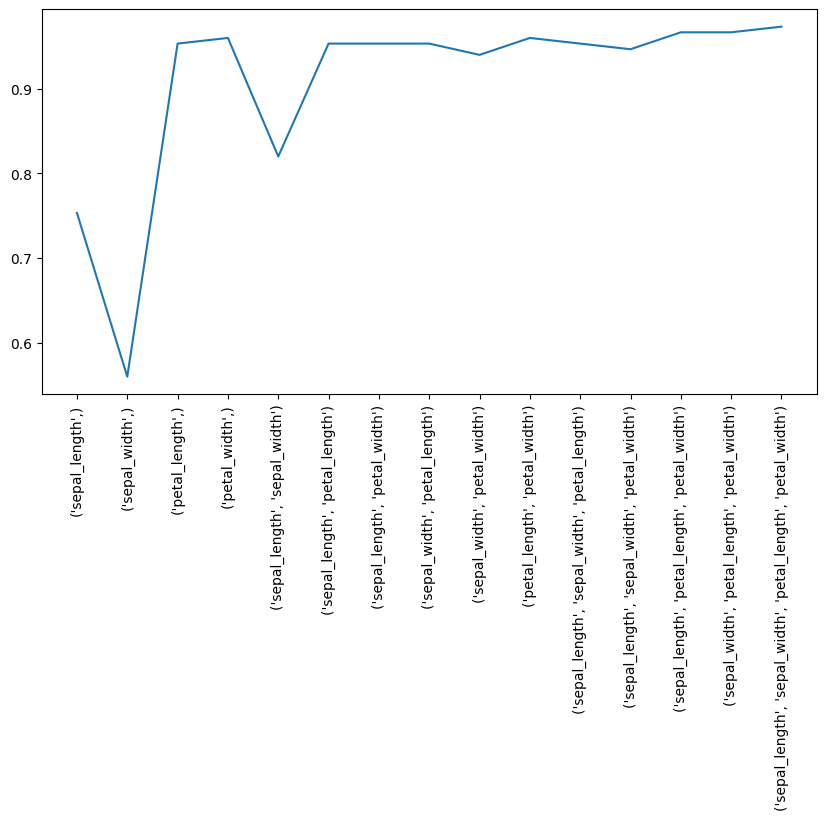

In [8]:
# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot([str(k) for k in matric_df['feature_names']], matric_df['avg_score'])
plt.xticks(rotation=90)
plt.show()

#### Regression Example

In [9]:
# Loading the dataset
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [10]:
# Splitting
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df['medv'], test_size=0.2, random_state=1)

print(X_train.shape)
print(X_test.shape)

(404, 13)
(102, 13)


In [11]:
# Basic Preprocessing
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [12]:
# Baseline Model
model = LinearRegression()
model.fit(X_train, y_train)

print("testing", np.mean(cross_val_score(model, X_test, y_test, cv=5, scoring='r2')))

testing 0.6514899901155404


In [13]:
# Training Feature Selector
exh = EFS(estimator=LinearRegression(), min_features=5, max_features=10, scoring='r2', cv=10, print_progress=True)
sel = exh.fit(X_train, y_train)

Features: 7007/7007

In [14]:
print(sel.best_score_)
print(sel.best_feature_names_)

0.6827988156800064
('0', '1', '4', '5', '7', '8', '9', '10', '11', '12')


In [15]:
metric_df = pd.DataFrame.from_dict(sel.get_metric_dict()).T
metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
0,"(0, 1, 2, 3, 4)","[0.3581348488328995, -0.04087953894999696, 0.0...",0.291545,"(0, 1, 2, 3, 4)",0.151561,0.204065,0.068022
1,"(0, 1, 2, 3, 5)","[0.7932990601442247, -0.028473314596647148, 0....",0.497074,"(0, 1, 2, 3, 5)",0.194673,0.262111,0.08737
2,"(0, 1, 2, 3, 6)","[0.3509360902647489, -0.018022556068318263, 0....",0.290928,"(0, 1, 2, 3, 6)",0.144403,0.194427,0.064809
3,"(0, 1, 2, 3, 7)","[0.48655631933866017, 0.048738467081783865, 0....",0.342819,"(0, 1, 2, 3, 7)",0.134873,0.181595,0.060532
4,"(0, 1, 2, 3, 8)","[0.3689547164872463, -0.03700155351221568, 0.0...",0.282304,"(0, 1, 2, 3, 8)",0.149644,0.201483,0.067161
...,...,...,...,...,...,...,...
7002,"(2, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.8219264453501747, 0.5514749661425014, 0.441...",0.662559,"(2, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.094822,0.12767,0.042557
7003,"(2, 3, 4, 6, 7, 8, 9, 10, 11, 12)","[0.7459708312157864, 0.6697260005899279, 0.437...",0.640064,"(2, 3, 4, 6, 7, 8, 9, 10, 11, 12)",0.063856,0.085977,0.028659
7004,"(2, 3, 5, 6, 7, 8, 9, 10, 11, 12)","[0.8422107592440895, 0.5223754431725885, 0.390...",0.647146,"(2, 3, 5, 6, 7, 8, 9, 10, 11, 12)",0.101847,0.137128,0.045709
7005,"(2, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.8338271618404898, 0.599745851493561, 0.4116...",0.662428,"(2, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.09302,0.125244,0.041748


In [16]:
# Selecting based on adjusted-r2-scores
def adjust_r2(r2, num_examples, num_features):
    coef = (num_examples - 1) / (num_examples - num_features - 1)
    return 1 - (1 - r2) * coef

In [17]:
metric_df['observations'] = 404
metric_df['num_features'] = metric_df['feature_idx'].apply(lambda x: len(x))
metric_df['adjusted_r2'] = adjust_r2(metric_df['avg_score'], metric_df['observations'], metric_df['num_features'])

metric_df.sort_values('adjusted_r2', ascending=False)

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
6883,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)","[0.8855189158291968, 0.5742220049707852, 0.437...",0.682799,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)",0.096995,0.130595,0.043532,404,10,0.674728
6316,"(0, 1, 4, 5, 7, 8, 9, 10, 12)","[0.8717831363927702, 0.5819307800982587, 0.462...",0.680483,"(0, 1, 4, 5, 7, 8, 9, 10, 12)",0.090811,0.122269,0.040756,404,9,0.673185
6857,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 12)","[0.8609640874051024, 0.5450970257505903, 0.487...",0.679139,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 12)",0.093292,0.12561,0.04187,404,10,0.670974
6821,"(0, 1, 2, 4, 5, 7, 8, 9, 10, 12)","[0.8658054398863743, 0.5826458169186086, 0.462...",0.678834,"(0, 1, 2, 4, 5, 7, 8, 9, 10, 12)",0.08993,0.121083,0.040361,404,10,0.670662
6878,"(0, 1, 4, 5, 6, 7, 8, 9, 10, 12)","[0.8718471501454652, 0.5835459650053559, 0.458...",0.678669,"(0, 1, 4, 5, 6, 7, 8, 9, 10, 12)",0.090869,0.122347,0.040782,404,10,0.670493
...,...,...,...,...,...,...,...,...,...,...
1939,"(0, 3, 7, 8, 9, 11)","[0.34947531428136125, -0.026414757786285215, -...",0.224191,"(0, 3, 7, 8, 9, 11)",0.136983,0.184435,0.061478,404,6,0.212466
354,"(0, 3, 7, 9, 11)","[0.31219535089682926, 0.028977593398892276, -0...",0.212198,"(0, 3, 7, 9, 11)",0.135674,0.182673,0.060891,404,5,0.202301
349,"(0, 3, 7, 8, 9)","[0.30500414759817773, -0.03718390147543138, -0...",0.211156,"(0, 3, 7, 8, 9)",0.144578,0.194662,0.064887,404,5,0.201246
1147,"(3, 7, 8, 9, 11)","[0.3414449494602596, -0.04945658558324717, -0....",0.198625,"(3, 7, 8, 9, 11)",0.145562,0.195987,0.065329,404,5,0.188558


In [18]:
# There is a small difference between r2 scores and adjusted r2 scores - But the order of feature sets are same
X_train_sel = sel.transform(X_train)
X_test_sel = sel.transform(X_test)

In [19]:
print("training", np.mean(cross_val_score(LinearRegression(), X_train_sel, y_train, cv=5, scoring='r2')))
print("testing", np.mean(cross_val_score(LinearRegression(), X_test_sel, y_test, cv=5, scoring='r2')))

training 0.7100327839218561
testing 0.7205819296124483


---

#### Backward Elimination
Sequential Backward Elimination (SBE) is a wrapper-based feature selection technique that starts with the full set of features and iteratively removes the least significant ones.

##### How it Works
1. **Initial Model**: Start by training a model with all available features and record its performance as the baseline.
2. **Feature Removal**: Systematically remove one feature at a time to create all possible subsets containing $n-1$ features.
3. **Evaluation**: Train models for each subset and identify the one that yields the highest performance.
4. **Iteration**: Repeat the process by removing one feature from the best subset found in the previous step to create subsets of size $n-2$, $n-3$, and so on.
5. **Selection**: Compare the best-performing subsets from each iteration and select the optimal feature set based on the desired performance metric.

In [20]:
# Loading the data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# load the dataset
data = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')

# separate the target variable
X = data.drop("medv", axis=1)
y = data['medv']

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(X_train.shape)

(404, 13)


In [21]:
# Basic Preprocessing
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [22]:
# Model training and cross-validation
model = LinearRegression()

print("training", np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='r2')))
print("testing", np.mean(cross_val_score(model, X_test, y_test, cv=5, scoring='r2')))

training 0.7025123301096213
testing 0.6514899901155404


In [25]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# perform backward elimination -> forward=False - Backward
sbe = SFS(LinearRegression(), k_features='best', forward=False, floating=False, scoring='r2', cv=5)
sbe.fit(X_train, y_train)

,estimator,LinearRegression()
,k_features,"(1, ...)"
,forward,False
,floating,False
,verbose,0
,scoring,'r2'
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [26]:
# Selected feature indices
sbe.k_feature_idx_

(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)

In [27]:
# Calculating adjusted r2-score
metric_df = pd.DataFrame.from_dict(sbe.get_metric_dict()).T

metric_df['observations'] = 404
metric_df['num_features'] = metric_df['feature_idx'].apply(lambda x: len(x))
metric_df['adjusted_r2'] = adjust_r2(metric_df['avg_score'],metric_df['observations'],metric_df['num_features'])

metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
13,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.7535027170817177, 0.6920238509138777, 0.682...",0.702512,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.038207,0.029727,0.014863,404,13,0.692596
12,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7532855958710694, 0.6944570477695305, 0.693...",0.70581,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.035641,0.02773,0.013865,404,12,0.696781
11,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7547108925568492, 0.6959627893665098, 0.701...",0.708109,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.035367,0.027516,0.013758,404,11,0.699918
10,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7769593921905563, 0.6884741223718952, 0.702...",0.710033,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)",0.046075,0.035848,0.017924,404,10,0.702654
9,"(0, 1, 4, 5, 7, 8, 9, 10, 12)","[0.7706104220711025, 0.6854023389684323, 0.690...",0.704324,"(0, 1, 4, 5, 7, 8, 9, 10, 12)",0.046449,0.036139,0.018069,404,9,0.69757
8,"(0, 1, 4, 5, 7, 8, 10, 12)","[0.7681719744800459, 0.6822126526818693, 0.670...",0.697727,"(0, 1, 4, 5, 7, 8, 10, 12)",0.04882,0.037984,0.018992,404,8,0.691605
7,"(0, 1, 4, 5, 7, 10, 12)","[0.7671638009750725, 0.6812300799626649, 0.661...",0.692234,"(0, 1, 4, 5, 7, 10, 12)",0.051644,0.040181,0.02009,404,7,0.686794
6,"(1, 4, 5, 7, 10, 12)","[0.7519120213497091, 0.6756087674652564, 0.646...",0.686004,"(1, 4, 5, 7, 10, 12)",0.046845,0.036447,0.018224,404,6,0.681258
5,"(4, 5, 7, 10, 12)","[0.7525552802357769, 0.6665033988504308, 0.639...",0.681065,"(4, 5, 7, 10, 12)",0.051233,0.039861,0.019931,404,5,0.677058
4,"(5, 7, 10, 12)","[0.7384743962575444, 0.640118850766883, 0.5873...",0.662544,"(5, 7, 10, 12)",0.063384,0.049315,0.024658,404,4,0.659161


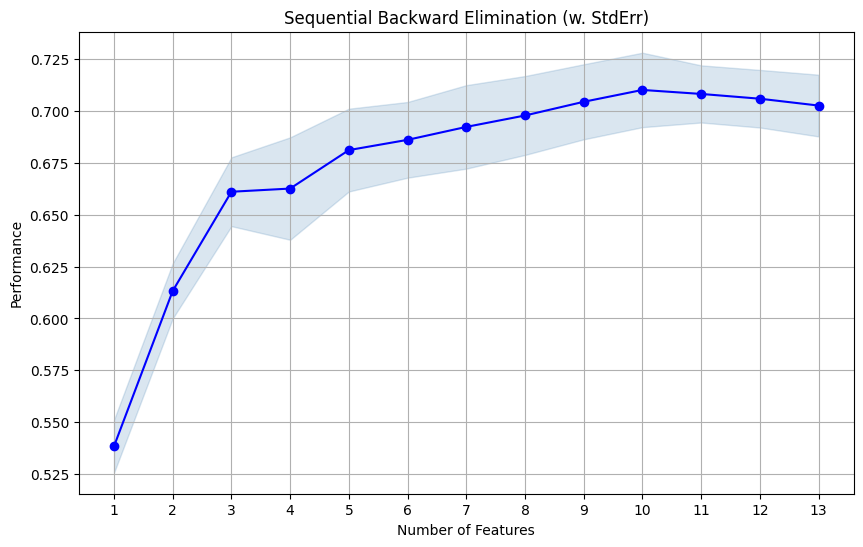

In [28]:
# Performance over every feature subset
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig1 = plot_sfs(sbe.get_metric_dict(), kind='std_err', figsize=(10, 6))
plt.title('Sequential Backward Elimination (w. StdErr)')
plt.grid()
plt.show()

In [29]:
X_train_sel = sbe.transform(X_train)
X_test_sel = sbe.transform(X_test)

model = LinearRegression()

print("training",np.mean(cross_val_score(model, X_train_sel, y_train, cv=5, scoring='r2')))
print("testing",np.mean(cross_val_score(model, X_test_sel, y_test, cv=5, scoring='r2')))

training 0.7100327839218561
testing 0.7205819296124483


In [30]:
X_train_sel.shape

(404, 10)

In [31]:
# Using scikit-learn
from sklearn.feature_selection import SequentialFeatureSelector as SFS

sbe = SFS(
    estimator=model,
    n_features_to_select=5, # exact 5 features
    direction='backward',
    scoring='r2',
    cv=5
)

sbe.fit(X_train, y_train)

,estimator,LinearRegression()
,n_features_to_select,5
,tol,None
,direction,'backward'
,scoring,'r2'
,cv,5
,n_jobs,None
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [32]:
# selected feature indices
np.arange(X.shape[1])[sbe.support_]

array([ 4,  5,  7, 10, 12])

#### Disadvantages of Backward Elimination

1. **Computationally Expensive**: It starts with the full set of features, making it significantly slower than Forward Selection, especially when the number of features ($p$) is very large.
2. **Irreversible Process**: Once a feature is removed, it cannot be re-added to the model. This greedy approach might miss the optimal feature subset if a removed feature becomes significant only in combination with a different subset.

---

#### Forward Selection
Sequential Forward Selection (SFS) is a wrapper-based feature selection technique that starts with an empty set of features and iteratively adds the most significant ones.

##### How it Works
1. **Initial Model**: Start with an empty set of features (null model).
2. **Feature Addition**: Systematically add one feature at a time from the pool of available features to create all possible subsets containing $1$ feature.
3. **Evaluation**: Train models for each subset and identify the one that yields the highest performance improvement.
4. **Iteration**: Repeat the process by adding one feature from the remaining set to the best subset found in the previous step to create subsets of size $2$, $3$, and so on.
5. **Selection**: Compare the best-performing subsets from each iteration and select the optimal feature set based on the desired performance metric or until no further improvement is observed.

In [34]:
# Training feature selector
from sklearn.feature_selection import SequentialFeatureSelector

SFS = SequentialFeatureSelector(
    estimator=LinearRegression(),
    n_features_to_select=5,
    direction="forward",
    scoring="r2",
    cv=5
)

sfs = SFS.fit(X_train, y_train)
sfs

,estimator,LinearRegression()
,n_features_to_select,5
,tol,None
,direction,'forward'
,scoring,'r2'
,cv,5
,n_jobs,None
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [ ]:
# Selected featutes
np.arange(X_train.shape[1])[sfs.get_support()]

array([ 5,  7, 10, 11, 12])

In [36]:
X_train_sel = sfs.transform(X_train)
X_test_sel = sfs.transform(X_test)

#### Disadvantages of Forward Selection

1. **Irreversible Process**: Once a feature is added to the model, it cannot be removed. This greedy approach might miss the optimal feature subset if a feature added early becomes redundant or less useful when combined with later additions.
2. **Greedy Nature**: It does not account for feature interactions. A feature that is not significant individually but highly significant when combined with others might never be selected if it doesn't provide enough initial improvement.

---